# Model comparison for bus demand forecasting

This notebook compares baseline models on the 8 forecasting setups:

- `pohang -> seoul` with horizons `d`, `d+1`, `d+3`, `d+7`
- `seoul -> pohang` with horizons `d`, `d+1`, `d+3`, `d+7`

It produces:

- a comparison table,
- line plots for MAE / RMSE / R²,
- best-model summaries,


## 1. Imports

In [14]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


## 2. Load the model comparison results

In [26]:
path = Path('../results/model_comparison_baselines.csv')
if path.exists():
    print(f'File loaded successfully.')
else:
    print(f'Could not load the file.')

df = pd.read_csv(path)
df.head()

File loaded successfully.


,origin,destination,horizon_days,model,mae_test,rmse_test,r2_test
0,pohang,seoul,0,Dummy,385.033238,584.749360,-0.334618
1,pohang,seoul,1,Dummy,385.033238,584.749360,-0.334618
2,pohang,seoul,3,Dummy,385.033238,584.749360,-0.334618
3,pohang,seoul,7,Dummy,385.033238,584.749360,-0.334618
4,pohang,seoul,0,LinearRegression,405.226013,500.313477,0.022983


## 3. Clean up and order categories

In [27]:
horizon_order = ['d', 'd+1', 'd+3', 'd+7']
model_order = ['Dummy', 'LinearRegression', 'Ridge', 'XGBoost']

df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

df = df[df['model'].notna()].copy()
df = df.sort_values(['origin', 'destination', 'horizon_days', 'model']).reset_index(drop=True)

display(df)

,origin,destination,horizon_days,model,mae_test,rmse_test,r2_test
0,pohang,seoul,0,Dummy,385.033238,584.749360,-0.334618
1,pohang,seoul,0,LinearRegression,405.226013,500.313477,0.022983
2,pohang,seoul,0,Ridge,400.305389,496.781342,0.036730
3,pohang,seoul,0,XGBoost,172.424225,319.604919,0.601302
4,pohang,seoul,1,Dummy,385.033238,584.749360,-0.334618
5,pohang,seoul,1,LinearRegression,407.036652,499.650482,0.025571
6,pohang,seoul,1,Ridge,397.954987,492.056946,0.054964
7,pohang,seoul,1,XGBoost,172.618729,312.483826,0.618870
8,pohang,seoul,3,Dummy,385.033238,584.749360,-0.334618
9,pohang,seoul,3,LinearRegression,410.441315,505.735382,0.001693


## 4. Overall summary by route and model

In [17]:
summary = (
    df.groupby(['origin', 'destination', 'model'], as_index=False)[['mae_test', 'rmse_test', 'r2_test']]
      .mean()
      .sort_values(['origin', 'destination', 'model'])
      .reset_index(drop=True)
)

display(summary)

,origin,destination,model,mae_test,rmse_test,r2_test
0,pohang,seoul,Dummy,385.033238,584.749360,-0.334618
1,pohang,seoul,LinearRegression,404.090569,501.957207,0.016531
2,pohang,seoul,Ridge,394.762039,492.796120,0.052075
3,pohang,seoul,XGBoost,175.701515,319.235390,0.601714
4,seoul,pohang,Dummy,385.679003,567.689350,-0.316570
5,seoul,pohang,LinearRegression,393.517906,488.212616,0.024945
6,seoul,pohang,Ridge,392.043747,485.755112,0.034686
7,seoul,pohang,XGBoost,163.917755,283.933281,0.670556


## 5. Best model per route and horizon

In [19]:
best_per_case = (
    df.sort_values(['origin', 'destination', 'horizon_days', 'mae_test'])
      .groupby(['origin', 'destination', 'horizon_days'], as_index=False)
      .first()
)

display(best_per_case[['origin', 'destination', 'horizon_days', 'model', 'mae_test', 'rmse_test', 'r2_test']])

print('Best model counts:')
display(best_per_case['model'].value_counts(dropna=False).to_frame('count'))

,origin,destination,horizon_days,model,mae_test,rmse_test,r2_test
0,pohang,seoul,0,XGBoost,172.424225,319.604919,0.601302
1,pohang,seoul,1,XGBoost,172.618729,312.483826,0.618870
2,pohang,seoul,3,XGBoost,170.605988,307.340607,0.631313
3,pohang,seoul,7,XGBoost,187.157120,337.512207,0.555372
4,seoul,pohang,0,XGBoost,161.355820,281.916840,0.675313
5,seoul,pohang,1,XGBoost,168.759888,284.915802,0.668369
6,seoul,pohang,3,XGBoost,162.847824,277.813904,0.684695
7,seoul,pohang,7,XGBoost,162.707489,291.086578,0.653848


Best model counts:


,count
model,
XGBoost,8
Dummy,0
LinearRegression,0
Ridge,0
LightGBM,0


## 6. Line plots by route

Each subplot shows the metric across horizons for all available models.

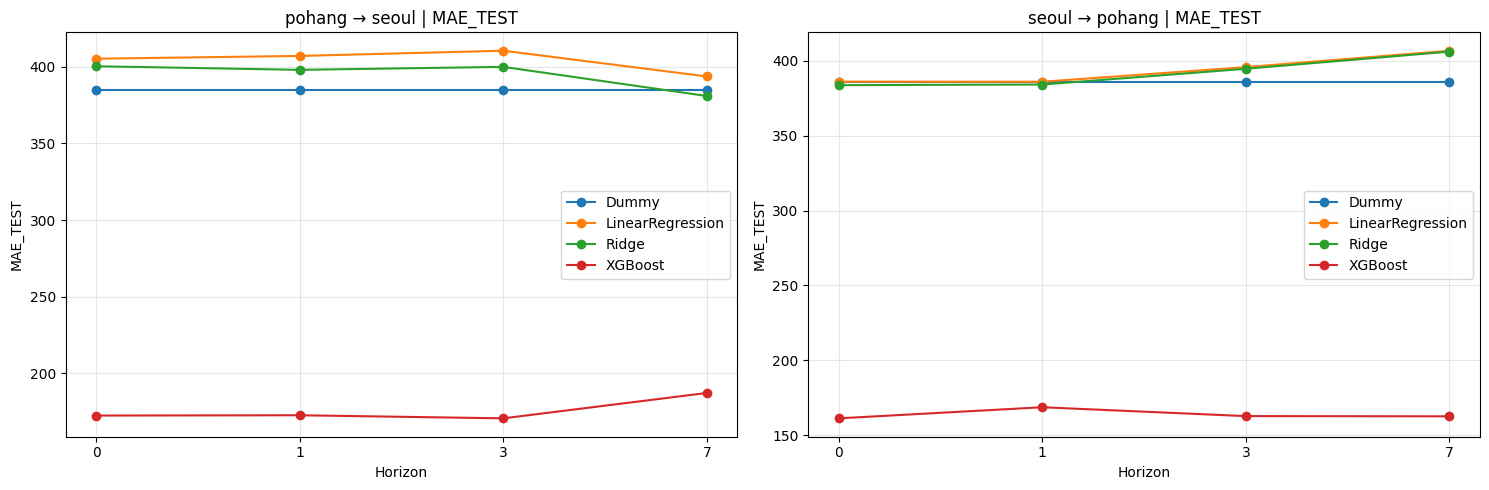

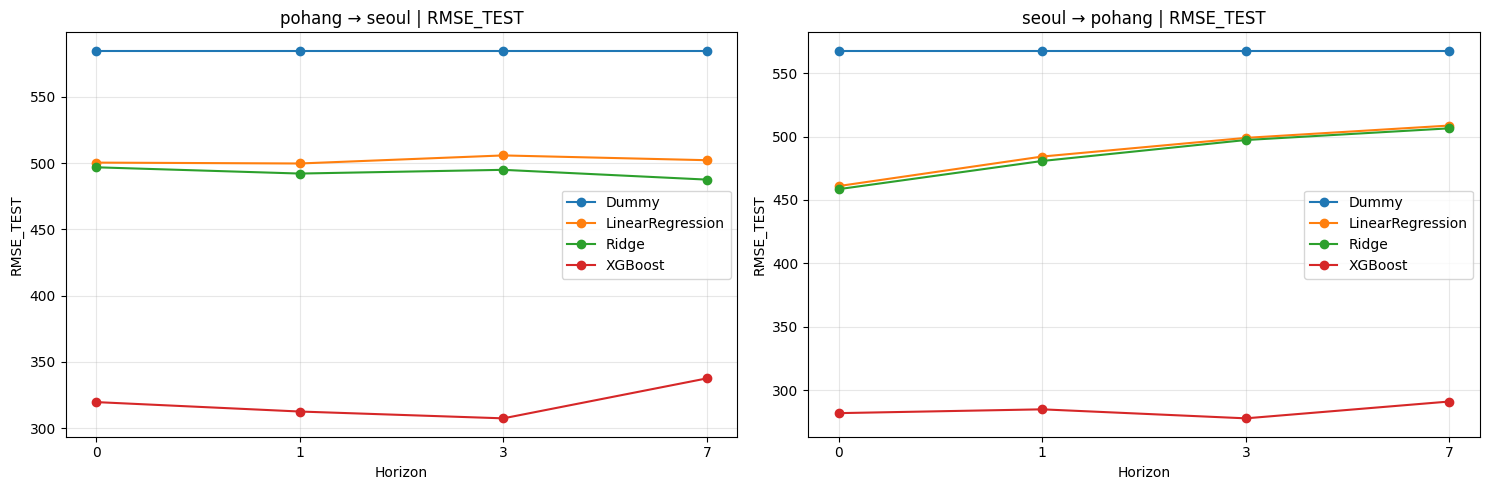

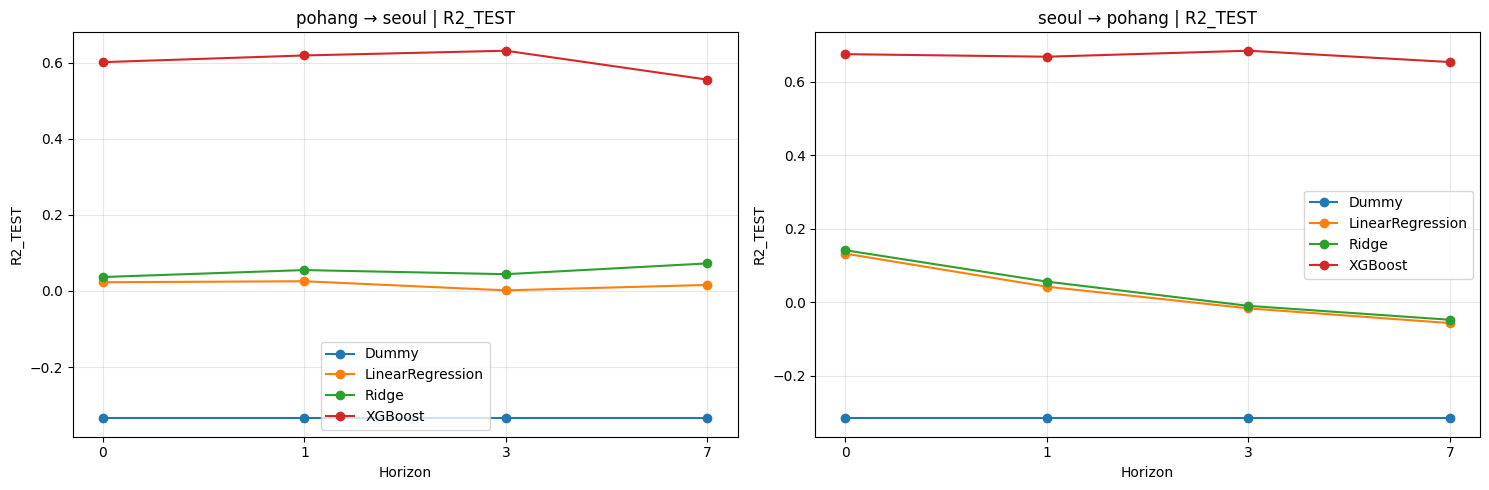

In [21]:
metrics = ['mae_test', 'rmse_test', 'r2_test']
routes = [
    ('pohang', 'seoul'),
    ('seoul', 'pohang'),
]

for metric in metrics:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
    
    for ax, (origin, destination) in zip(axes, routes):
        sub = df[(df['origin'] == origin) & (df['destination'] == destination)].copy()
        sub = sub.sort_values(['horizon_days', 'model'])

        for model in [m for m in model_order if m in sub['model'].astype(str).unique()]:
            m = sub[sub['model'].astype(str) == model]
            if len(m) == 0:
                continue
            ax.plot(m['horizon_days'].astype(str), m[metric], marker='o', label=model)

        ax.set_title(f'{origin} → {destination} | {metric.upper()}')
        ax.set_xlabel('Horizon')
        ax.set_ylabel(metric.upper())
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

## 7. Mean metric comparison by model

This gives a compact view of which model is better on average for each route.

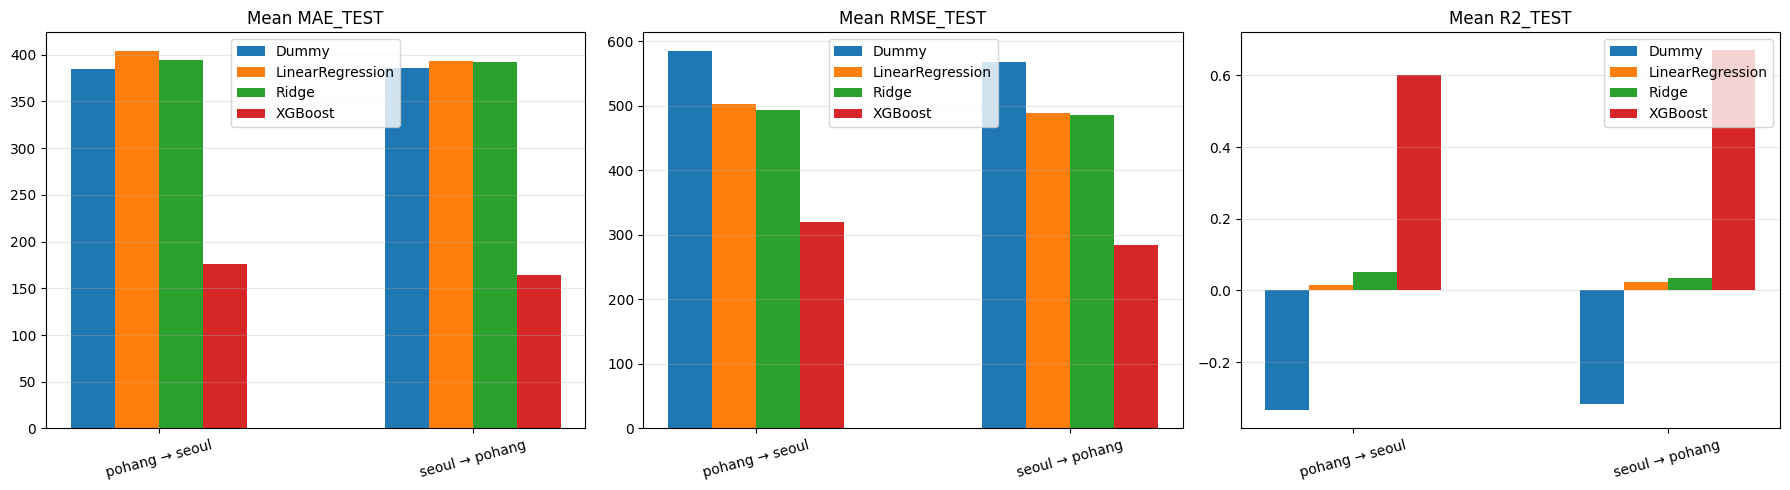

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    tmp = (
        df.groupby(['origin', 'destination', 'model'], as_index=False)[metric]
          .mean()
    )
    tmp['route'] = tmp['origin'] + ' → ' + tmp['destination']
    routes_list = tmp['route'].unique().tolist()
    x = np.arange(len(routes_list))
    width = 0.14

    available_models = [m for m in model_order if m in tmp['model'].astype(str).unique()]
    for i, model in enumerate(available_models):
        vals = []
        for route in routes_list:
            row = tmp[(tmp['route'] == route) & (tmp['model'].astype(str) == model)]
            vals.append(float(row[metric].iloc[0]))
        ax.bar(x + (i - (len(available_models)-1)/2) * width, vals, width, label=model)

    ax.set_title(f'Mean {metric.upper()}')
    ax.set_xticks(x)
    ax.set_xticklabels(routes_list, rotation=15)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()